In [1]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib
from sklearn.model_selection import GroupShuffleSplit

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

df = df[df['Length'] <= 500].copy()

df = df[df['Length'] <= 500].copy()

df["null"] = 0 

# 2. Initialize the Group Splitter
# n_splits=1 gives you a single train/test split (like train_test_split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state= 42)

# 3. Generate the indices
# We pass the 'question_id_external' column as the 'groups' parameter
train_idx, test_idx = next(gss.split(df, groups=df['question_id_external']))

# 4. Create your new DataFrames
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)
Train shape: (2699, 28)
Test shape: (1175, 28)


In [ ]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap"], test_df = test_df, min_clusters = 5, plot = False)

logistic_predictor = utils.run_detailed_logistic_regression(train_df, features=["Entropy", "Length", "Mechanistic", "LogitGap"], test_df = test_df, plot = False)


heavy_cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency", "Heuristic"], test_df = test_df, min_clusters = 5, plot = False)



utils.run_expanded_comparison(
    train_df, 
    {'Logistic Regression': logistic_predictor},  # <--- Fix (Dict)
    {'Cluster Baseline': cluster_predictor},      # <--- Fix (Dict)
    ["Entropy", "Length", "Mechanistic", "LogitGap"], 
    test_df=test_df
)

TypeError: run_expanded_comparison() got multiple values for argument 'test_df'

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+1.53 SD,0.121,0.118,0.02,
Semantic,+2.22 SD,1.018,0.972,0.28,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.38 SD,0.043,0.042,0.01,
Semantic,+0.00 SD,-0.000,-0.000,0.00,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.12 SD,0.060,0.061,0.02,
Semantic,+1.55 SD,0.735,0.677,0.23,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.71 SD,0.084,0.085,0.02,


Generating t-SNE on Train & Test Analysis...


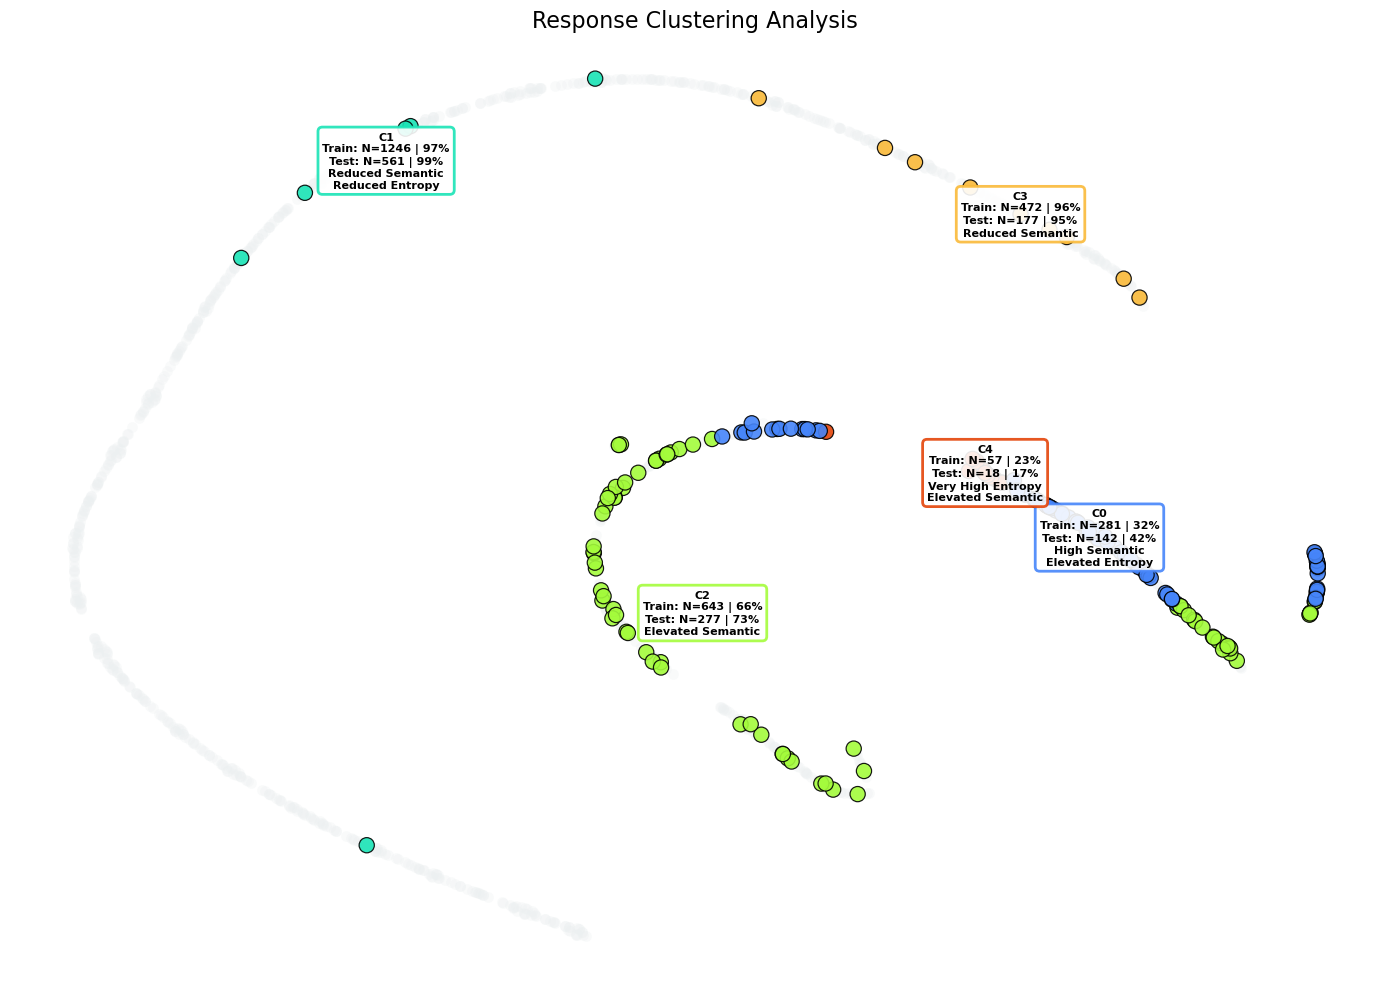

Generating Difficulty Stratification Plots...
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


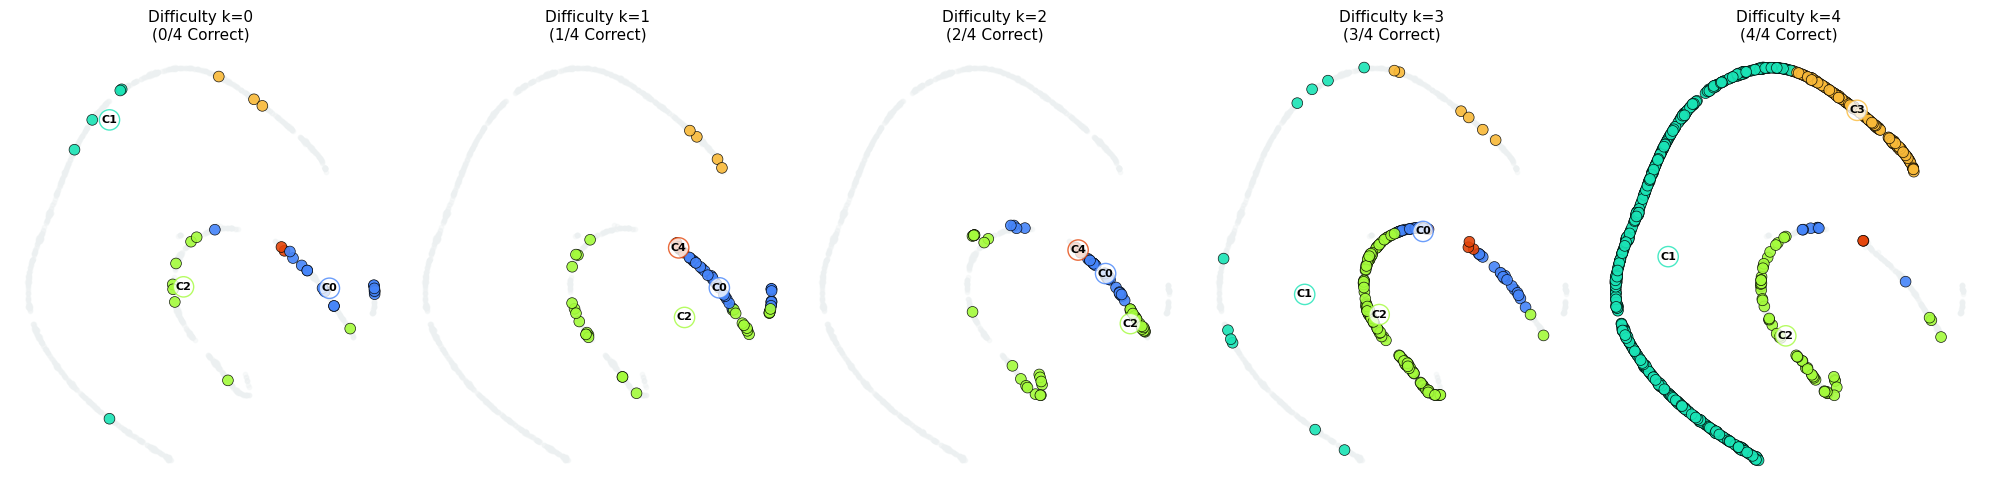

Generating Discrimination Bar Chart...


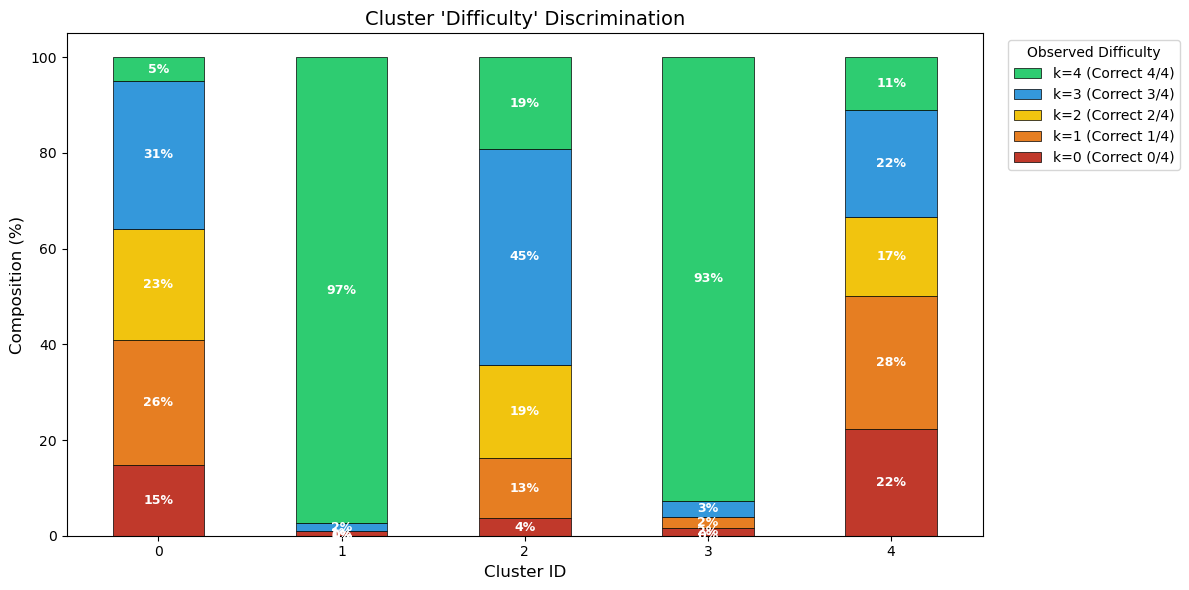


--- Pairwise Cluster Comparison (Same Question Overlap) ---


/Users/sadigulcelik/Documents/CompSci/ScalingLLM-2025-Fall/Uncertainty-Aware-Error-Detection-and-Recovery/analysis_utils.py:890: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_diff, subset=['Train_Diff', 'Test_Diff'])


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (32.0%) vs C2 (65.6%),105,-28.3%,49,-23.5%
1,C0 (32.0%) vs C4 (22.8%),36,+18.1%,9,+50.0%
2,C1 (97.1%) vs C3 (96.0%),217,+0.8%,78,+2.4%
3,C1 (97.1%) vs C4 (22.8%),4,+25.0%,1,+0.0%
4,C2 (65.6%) vs C4 (22.8%),18,+60.2%,7,+100.0%
5,C3 (96.0%) vs C4 (22.8%),4,+25.0%,2,+0.0%


In [3]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Semantic"], test_df = test_df, min_clusters = 5)

### Full Logistic Regression Analysis

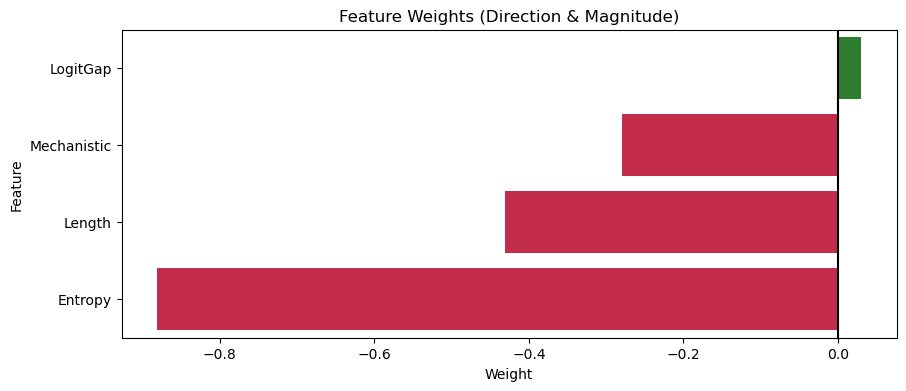

              precision    recall  f1-score   support

           0       0.37      0.70      0.48       188
           1       0.93      0.77      0.84       987

    accuracy                           0.76      1175
   macro avg       0.65      0.74      0.66      1175
weighted avg       0.84      0.76      0.78      1175



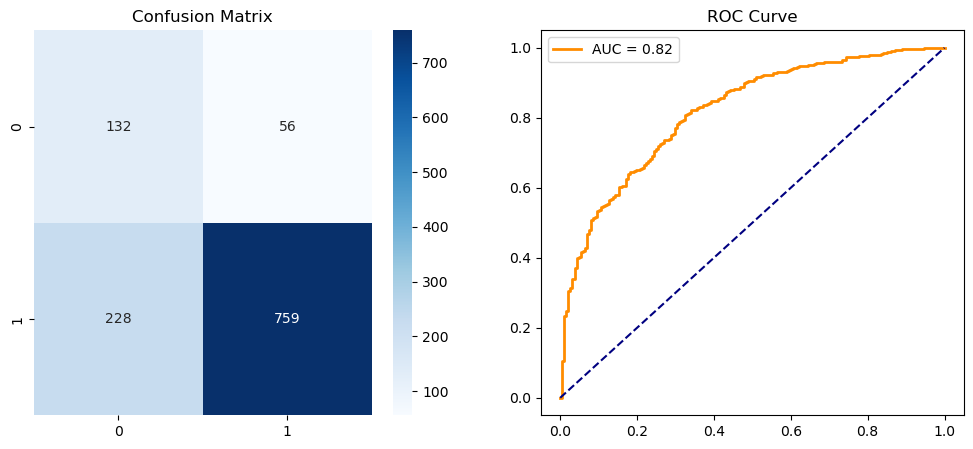

### Full Logistic Regression Analysis

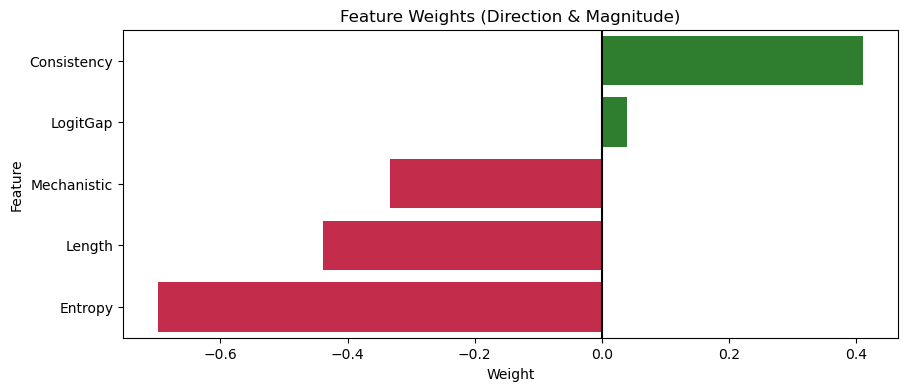

              precision    recall  f1-score   support

           0       0.38      0.73      0.50       188
           1       0.94      0.77      0.85       987

    accuracy                           0.77      1175
   macro avg       0.66      0.75      0.68      1175
weighted avg       0.85      0.77      0.79      1175



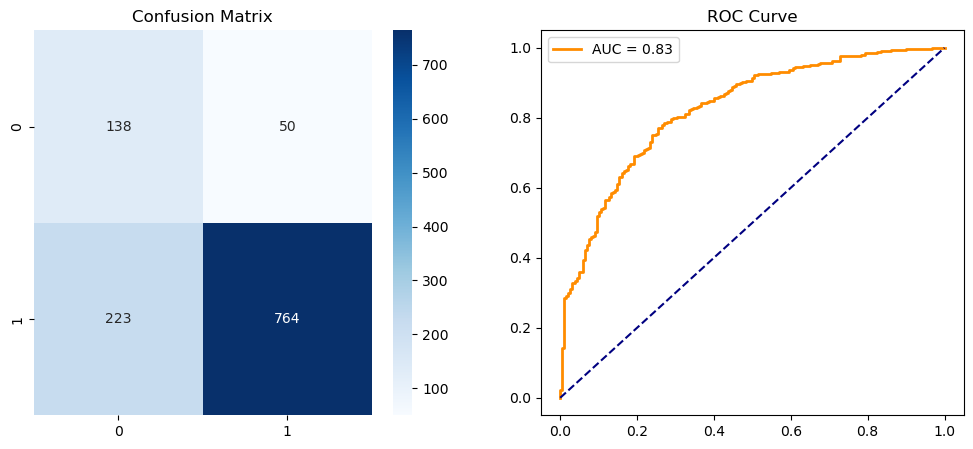

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+2.36 SD,0.153,0.151,0.05,
LogitGap,-0.15 SD,0.029,0.028,0.04,
Mechanistic,+1.26 SD,0.977,0.977,0.01,
Length,-0.03 SD,275.362,264.918,97.91,
Consistency,-1.24 SD,0.854,0.877,0.04,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.33 SD,0.044,0.044,0.01,
LogitGap,+0.33 SD,0.066,0.069,0.05,
Mechanistic,-1.13 SD,0.958,0.957,0.01,
Length,-0.38 SD,241.289,235.823,50.65,


Generating t-SNE on Train & Test Analysis...


KeyboardInterrupt: 

In [4]:


metrics_to_use = ['Entropy', 'LogitGap', 'Mechanistic','Length'] # 'Consistency', 

logistic_predictor = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use, test_df = test_df)

logistic_predictor_with_consistency = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use + ["Consistency"], test_df = test_df)



cluster_predictor_with_consistency = utils.run_failure_modes_dashboard(train_df, exp_info, features=metrics_to_use + ["Consistency"], test_df = test_df, min_clusters = 5)

In [ ]:
# 1. Capture Logistic Fusion Probabilities (Index 0)

for sdf in [df, train_df, test_df]:
    sdf['Logistic_Fusion'], _ = logistic_predictor(sdf)

    # 1. Capture Logistic Fusion Probabilities (Index 0)
    sdf['Logistic_Fusion_Consistency'], _ = logistic_predictor_with_consistency(sdf)

    # 2. Capture Cluster Labels (Index 1)
    _, sdf['Cluster_Label'] = cluster_predictor(sdf)

    # 3. (Optional) Capture Cluster Confidence if needed
    sdf['Cluster_Conf'], _ = cluster_predictor(sdf)

        # 2. Capture Cluster Labels (Index 1)
    _, sdf['Cluster_Label_Consistency'] = cluster_predictor_with_consistency(sdf)

    # 3. (Optional) Capture Cluster Confidence if needed
    sdf['Cluster_Conf_Consistency'], _ = cluster_predictor_with_consistency(sdf)

    # Verify
    print(sdf[['Logistic_Fusion', 'Cluster_Label']].head())

   Logistic_Fusion Cluster_Label
0              1.0     Cluster 3
1              1.0     Cluster 3
2              1.0     Cluster 3
3              1.0     Cluster 3
4              1.0     Cluster 3
   Logistic_Fusion Cluster_Label
0         0.817988     Cluster 3
1         0.896099     Cluster 3
2         0.892788     Cluster 3
3         0.897047     Cluster 3
4         0.516819     Cluster 2
    Logistic_Fusion Cluster_Label
24         0.723067     Cluster 1
25         0.732460     Cluster 4
26         0.719095     Cluster 1
27         0.765185     Cluster 4
40         0.677524     Cluster 3


In [ ]:
utils.run_comparison_dashboard(train_df, logistic_predictor, cluster_predictor, metrics_to_use, test_df = test_df)

,Train AUROC,Train ECE,Train MSE,Test AUROC,Test ECE,Test MSE
Model,,,,,,
Logistic Fusion,0.8016,0.2278,0.1782,0.8256,0.2298,0.1642
Cluster Baseline,0.7544,0.0000,0.1285,0.7561,0.0129,0.1123
Entropy,0.7525,0.0391,0.1339,0.8114,0.0464,0.1135
LogitGap,0.6349,0.6258,0.6722,0.6298,0.6503,0.6877
Mechanistic,0.7508,0.5867,0.4833,0.7667,0.6047,0.4861
Length,0.6380,0.3401,0.2660,0.6156,0.3488,0.2620


Model,Mn,Rg
Logistic Fusion,0.14,0.29
Cluster Baseline,0.45,0.41
Entropy,0.61,0.66
LogitGap,0.03,0.21
Mechanistic,0.10,0.30
Length,0.46,0.92
Model,Mn,Rg
Logistic Fusion,0.54,0.64
Cluster Baseline,0.79,0.55
Entropy,0.81,0.32


In [ ]:
utils.run_comparison_dashboard(train_df, logistic_predictor_with_consistency, cluster_predictor_with_consistency, metrics_to_use + ["Consistency"], test_df = test_df)

,Train AUROC,Train ECE,Train MSE,Test AUROC,Test ECE,Test MSE
Model,,,,,,
Logistic Fusion,0.8016,0.2278,0.1782,0.8256,0.2298,0.1642
Cluster Baseline,0.7544,0.0000,0.1285,0.7561,0.0129,0.1123
Entropy,0.7525,0.0391,0.1339,0.8114,0.0464,0.1135
LogitGap,0.6349,0.6258,0.6722,0.6298,0.6503,0.6877
Mechanistic,0.7508,0.5867,0.4833,0.7667,0.6047,0.4861
Length,0.6380,0.3401,0.2660,0.6156,0.3488,0.2620
Consistency,0.7085,0.0896,0.1522,0.7491,0.0746,0.1297


Model,Mn,Rg
Logistic Fusion,0.14,0.29
Cluster Baseline,0.45,0.41
Entropy,0.61,0.66
LogitGap,0.03,0.21
Mechanistic,0.10,0.30
Length,0.46,0.92
Consistency,0.85,0.26
Model,Mn,Rg
Logistic Fusion,0.54,0.64
Cluster Baseline,0.79,0.55


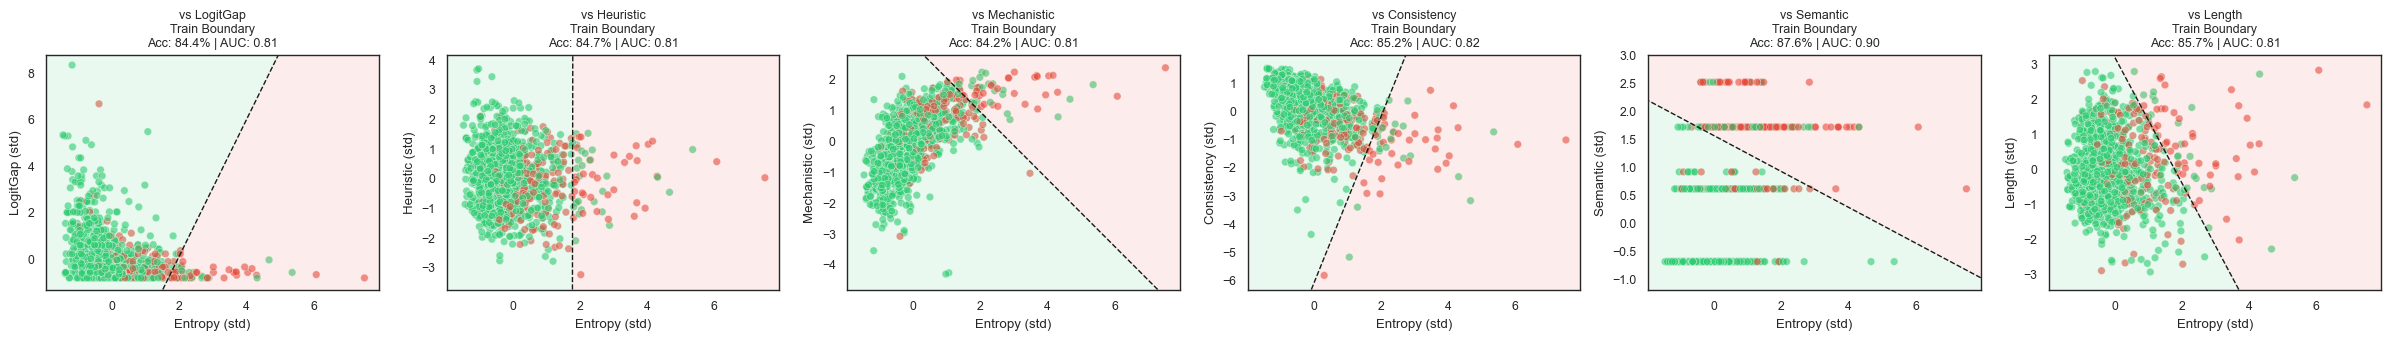

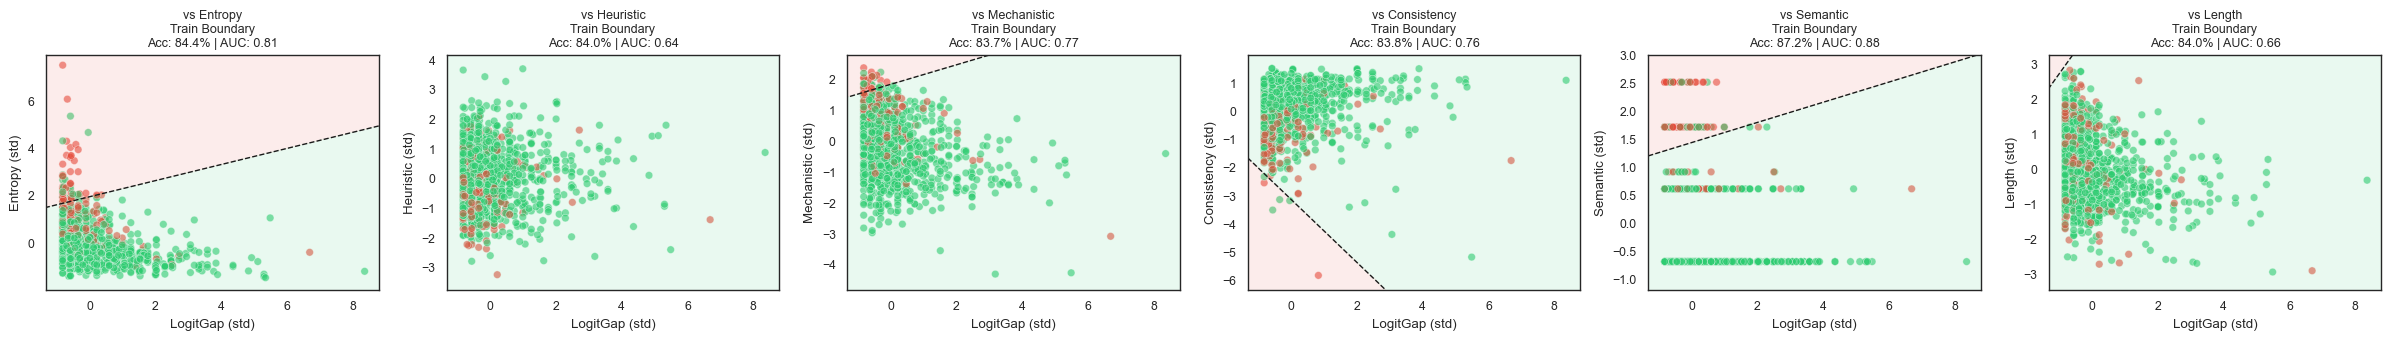

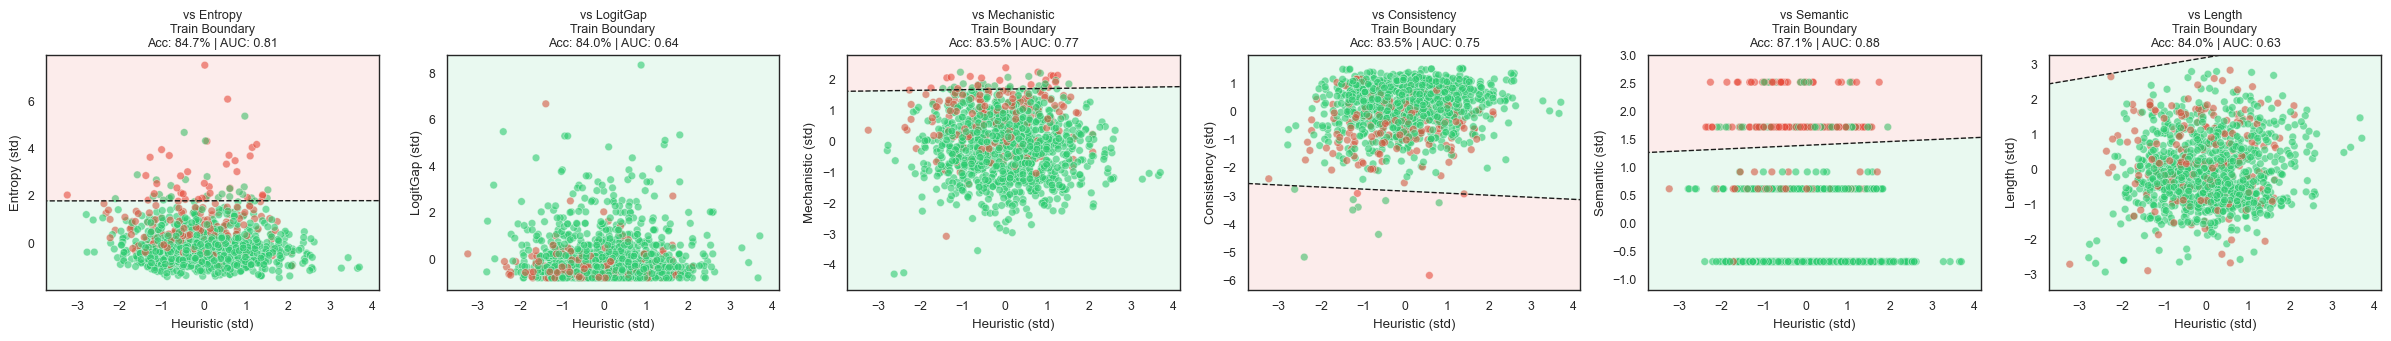

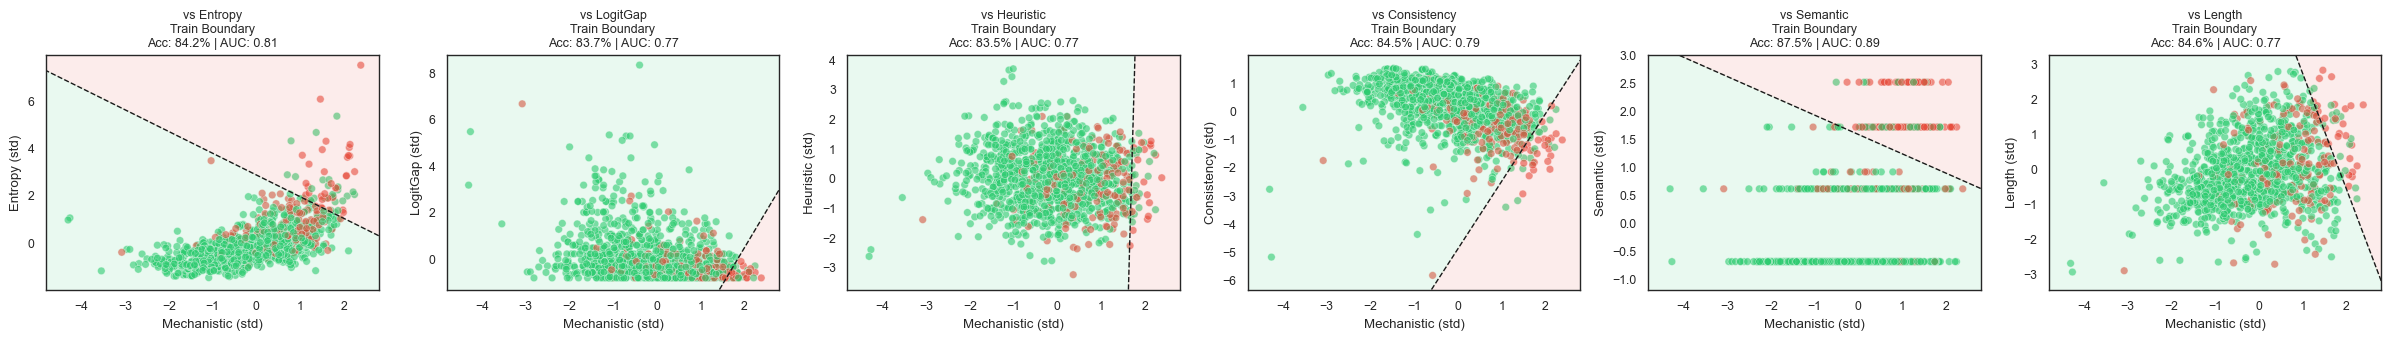

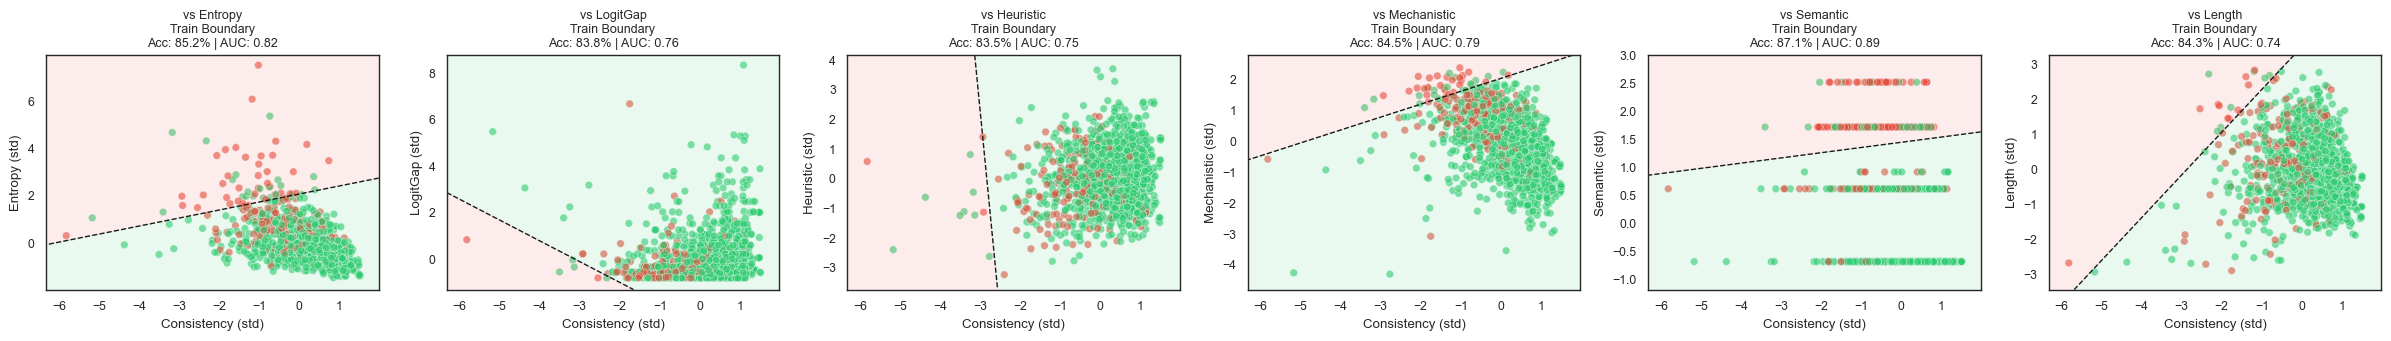

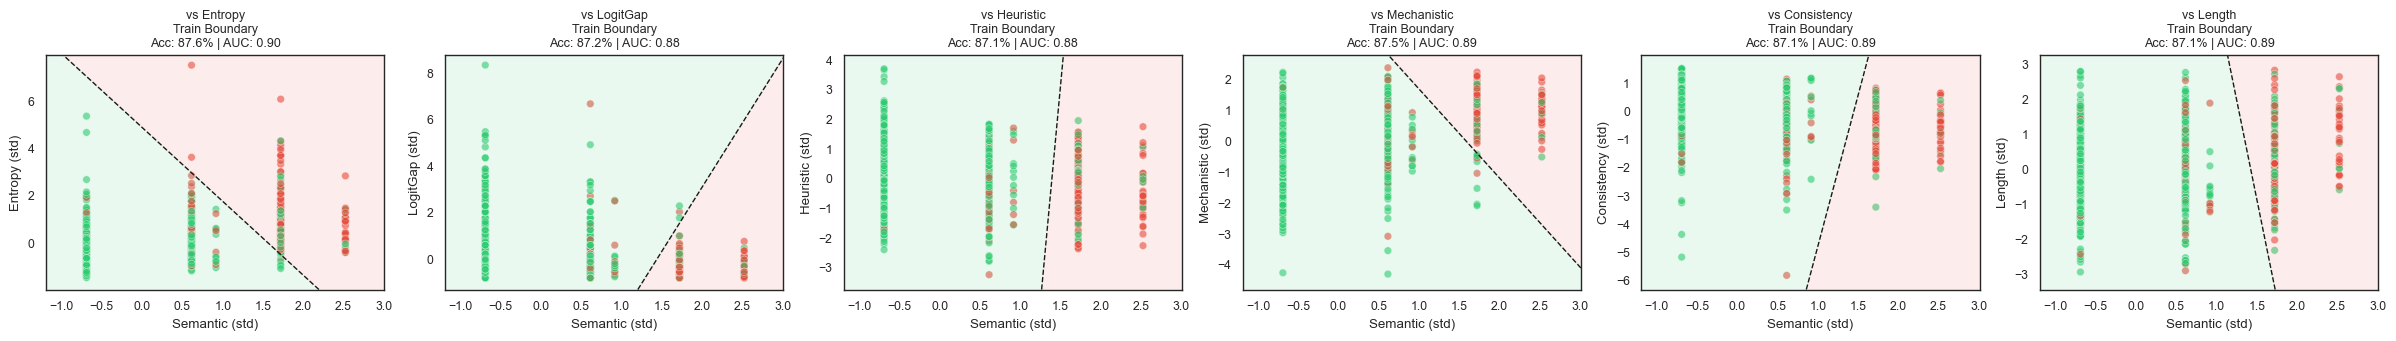

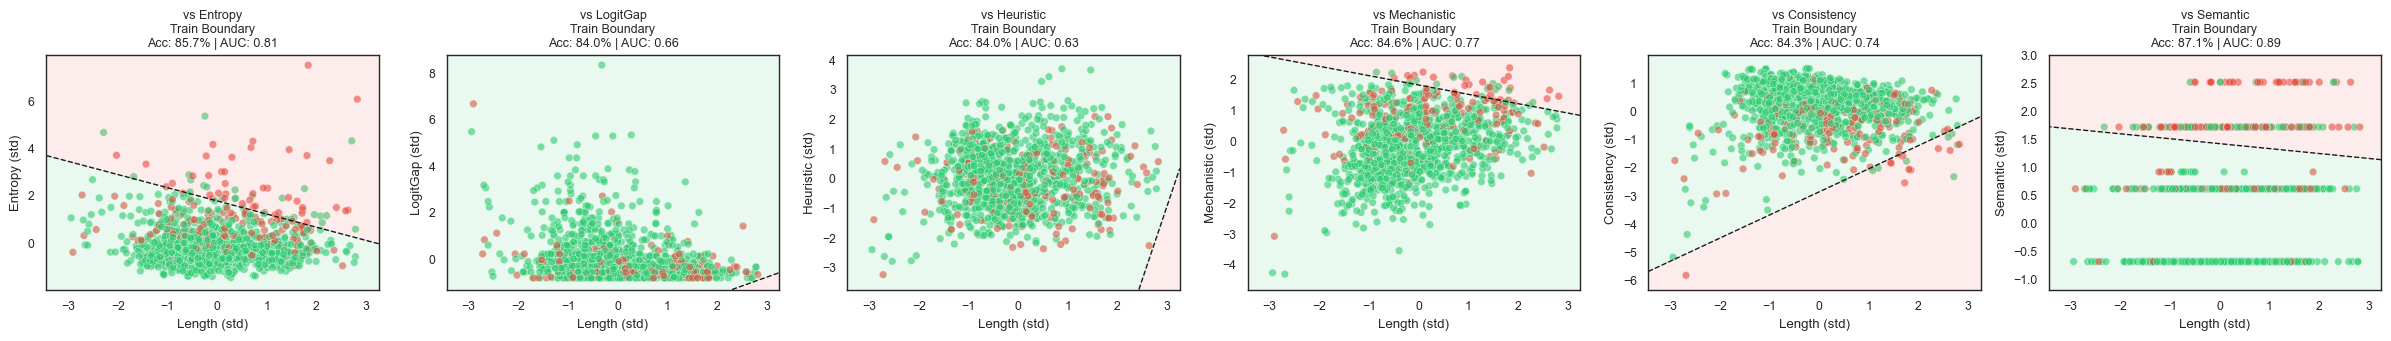

{'Entropy': <analysis_utils.PredictorArtifact at 0x35cfb7610>,
 'LogitGap': <analysis_utils.PredictorArtifact at 0x342947990>,
 'Heuristic': <analysis_utils.PredictorArtifact at 0x35cce31d0>,
 'Mechanistic': <analysis_utils.PredictorArtifact at 0x3437c2650>,
 'Consistency': <analysis_utils.PredictorArtifact at 0x34c559890>,
 'Semantic': <analysis_utils.PredictorArtifact at 0x344a6b190>,
 'Length': <analysis_utils.PredictorArtifact at 0x34c7c7a50>}

In [ ]:
utils.run_full_analysis(train_df,metrics, test_df = test_df)

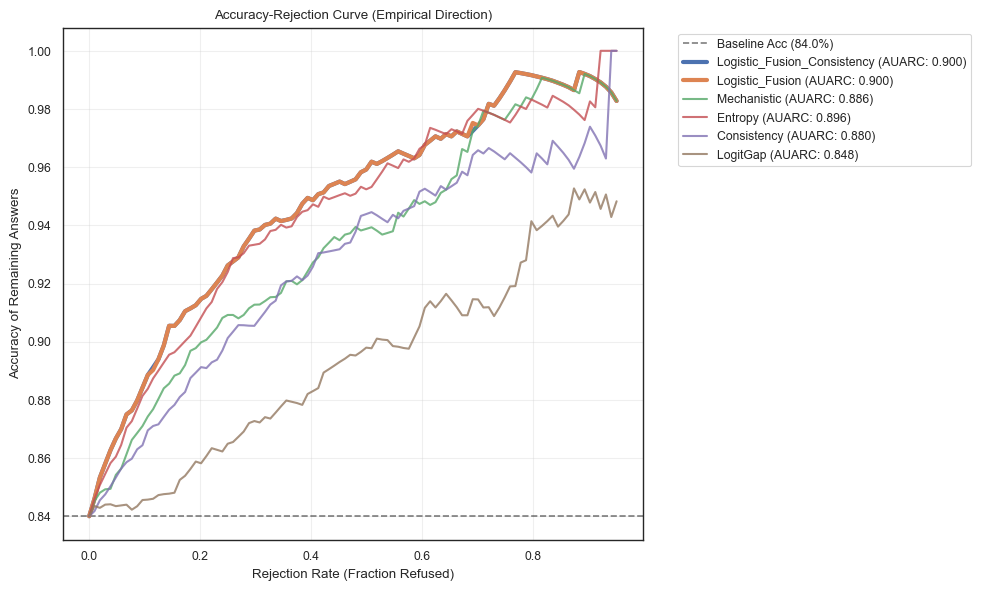

In [ ]:
cluster_accs = df.groupby('Cluster_Label')['Correct'].mean()
df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

metrics_to_plot = ["Logistic_Fusion_Consistency", "Logistic_Fusion", "Mechanistic", "Entropy", "Consistency", "LogitGap"] 

utils.plot_auarc_analysis(test_df, metrics_to_plot)

In [ ]:
df.keys()

Index(['result_id', 'question_id_external', 'question_text', 'gold_answer',
       'predicted_answer', 'full_trace_text', 'is_correct', 'Entropy',
       'LogitGap', 'Heuristic', 'Mechanistic', 'Consistency',
       'similarity_vector', 'uq_tokens', 'uq_mech_trace', 'uq_entropy_trace',
       'uq_logit_gap_trace', 'Correct', 'Semantic', 'Length', 'Entropy_Z',
       'LogitGap_Z', 'Heuristic_Z', 'Mechanistic_Z', 'Consistency_Z',
       'Semantic_Z', 'Length_Z', 'null', 'Logistic_Fusion',
       'Logistic_Fusion_Consistency', 'Cluster_Label', 'Cluster_Conf',
       'Cluster Baseline'],
      dtype='object')

In [ ]:
utils.analyze_outlier_clusters(df)

🔍 Analyzing 63 subsets on Train (n=2699) vs Test (n=1175)...


,Feature,Impact
4,Length,-2.73%
1,LogitGap,-1.24%
2,Heuristic,0.01%
5,Consistency,1.95%
3,Mechanistic,2.77%
0,Entropy,5.30%


,Size,Features,Acc_Best,Acc_Worst,Gap
10,2,"Entropy, Consistency",89.0%,74.9%,14.0%
27,3,"Entropy, Heuristic, Consistency",89.0%,74.9%,14.0%
29,3,"Entropy, Mechanistic, Consistency",89.0%,74.9%,14.0%
48,4,"Entropy, Heuristic, Mechanistic, Consistency",89.0%,74.9%,14.0%
6,2,"Entropy, LogitGap",89.3%,75.9%,13.4%
21,3,"Entropy, LogitGap, Heuristic",89.3%,75.9%,13.4%
0,1,Entropy,89.0%,75.6%,13.4%
57,5,"Entropy, LogitGap, Heuristic, Mechanistic, Consistency",88.0%,74.9%,13.0%
45,4,"Entropy, LogitGap, Mechanistic, Consistency",88.0%,74.9%,13.0%
7,2,"Entropy, Heuristic",89.0%,75.9%,13.0%


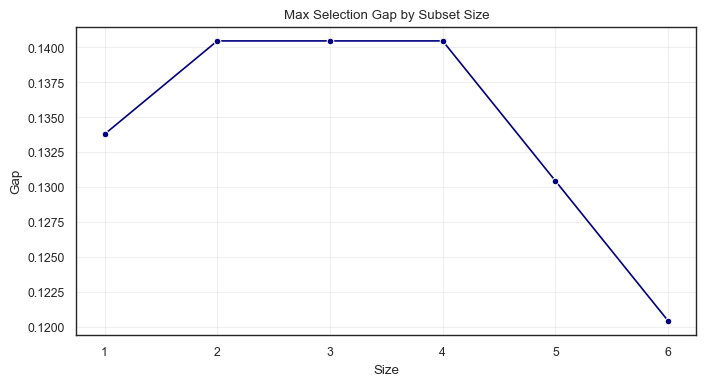

In [ ]:
def analyze_feature_redundancy(train_df, test_df):
    import itertools
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from IPython.display import display, HTML

    # 1. Configuration & Pre-processing
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length', "Consistency"]
    group_col = 'question_id_external' if 'question_id_external' in test_df.columns else 'question_text'
    
    # Scale based on TRAIN, apply to BOTH
    scaler = StandardScaler().fit(train_df[features].fillna(0))
    X_train = pd.DataFrame(scaler.transform(train_df[features].fillna(0)), columns=features, index=train_df.index)
    X_test = pd.DataFrame(scaler.transform(test_df[features].fillna(0)), columns=features, index=test_df.index)
    y_train = train_df['Correct']

    # Filter TEST set for multi-answer questions only
    mask_eval = test_df.groupby(group_col)[group_col].transform('count') > 1
    eval_df = test_df.loc[mask_eval, [group_col, 'Correct']].copy()
    
    if eval_df.empty: return print("⚠️ No multi-answer questions in Test DF.")

    print(f"🔍 Analyzing {2**len(features)-1} subsets on Train (n={len(train_df)}) vs Test (n={len(eval_df)})...")
    
    # 2. Brute-Force Search
    results = []
    # Generate all non-empty subsets
    subsets = itertools.chain.from_iterable(itertools.combinations(features, r) for r in range(1, len(features)+1))

    for subset in subsets:
        cols = list(subset)
        
        # Fit on TRAIN
        clf = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
        clf.fit(X_train[cols], y_train)
        
        # Predict on TEST
        eval_df['probs'] = clf.predict_proba(X_test.loc[eval_df.index, cols])[:, 1]
        
        # Identify Best/Worst candidates per question
        g = eval_df.groupby(group_col)['probs']
        best_idx, worst_idx = g.idxmax(), g.idxmin()
        
        # Filter: Model must distinguish items (Prob_Best != Prob_Worst)
        valid = eval_df.loc[best_idx, 'probs'].values != eval_df.loc[worst_idx, 'probs'].values
        
        if valid.any():
            acc_best = eval_df.loc[best_idx[valid], 'Correct'].mean()
            acc_worst = eval_df.loc[worst_idx[valid], 'Correct'].mean()
            results.append({
                'Size': len(cols), 'Features': ", ".join(cols),
                'Acc_Best': acc_best, 'Acc_Worst': acc_worst, 'Gap': acc_best - acc_worst
            })

    # 3. Aggregation
    res_df = pd.DataFrame(results).sort_values('Gap', ascending=False)
    
    # Impact Analysis: Gap (With Feature) - Gap (Without Feature)
    impact_data = []
    for f in features:
        mask = res_df['Features'].str.contains(f)
        impact = res_df[mask]['Gap'].mean() - res_df[~mask]['Gap'].mean()
        impact_data.append({'Feature': f, 'Impact': impact})
    
    impact_df = pd.DataFrame(impact_data).sort_values('Impact')

    # 4. Outputs
    # A. Variable Dispensability
    display(HTML("<h3>🗑️ Variable Dispensability (Low/Neg = Throw Out)</h3>"))
    display(HTML(impact_df.style.bar(subset=['Impact'], align='mid', color=['#e74c3c', '#27ae60'])
                 .format("{:.2%}", subset=['Impact']).to_html()))
    
    # B. Top Combinations
    display(HTML("<h3>🏆 Top 10 Feature Combinations</h3>"))
    display(HTML(res_df.head(10).style.background_gradient(subset=['Gap'], cmap='Greens')
                 .format("{:.1%}", subset=['Acc_Best', 'Acc_Worst', 'Gap']).to_html()))

    # C. Complexity Plot
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=res_df, x='Size', y='Gap', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Max Selection Gap by Subset Size")
    plt.grid(True, alpha=0.3); plt.show()

# Example Usage:
analyze_feature_redundancy(train_df, test_df)

🛡️ Applying Robust Group-wise Scaling...
🔍 Analyzing 63 subsets on Train (n=2699) vs Test (n=1175)...


,Feature,Marginal_Gain
0,Entropy,1.78%
3,Mechanistic,1.18%
5,Consistency,0.52%
2,Heuristic,0.06%
4,Length,0.01%
1,LogitGap,-0.69%


,Size,Features,Accuracy
44,4,"Entropy, LogitGap, Mechanistic, Length",89.30%
56,5,"Entropy, LogitGap, Heuristic, Mechanistic, Length",89.30%
9,2,"Entropy, Length",88.96%
22,3,"Entropy, LogitGap, Mechanistic",88.96%
21,3,"Entropy, LogitGap, Heuristic",88.96%
41,4,"Entropy, LogitGap, Heuristic, Mechanistic",88.96%
42,4,"Entropy, LogitGap, Heuristic, Length",88.96%
0,1,Entropy,88.96%
26,3,"Entropy, Heuristic, Length",88.96%
7,2,"Entropy, Heuristic",88.96%


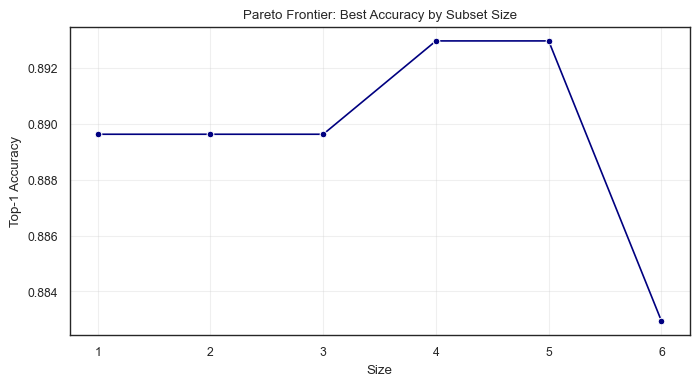

In [ ]:
def analyze_feature_redundancy_robust(train_df, test_df):
    import itertools
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from IPython.display import display, HTML

    # --- 1. Configuration ---
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length', "Consistency"]
    # Auto-detect group column
    group_col = 'question_id_external' if 'question_id_external' in test_df.columns else 'question_text'

    # --- 2. Robust Group-wise Scaling ---
    def group_scale_robust(df, cols, group_col):
        """
        Standardizes data within groups (Z-score). 
        Handles NaNs by imputing the Z-score with 0 (the group mean).
        Handles constant groups (std=0) to avoid division by zero.
        """
        # A. Create a safe copy & coerce Infs to NaN
        local_df = df.copy()
        local_df[cols] = local_df[cols].replace([np.inf, -np.inf], np.nan)
        
        # B. Group Statistics (Pandas ignores NaNs by default)
        grouped = local_df.groupby(group_col)[cols]
        means = grouped.transform('mean')
        stds = grouped.transform('std')
        
        # C. Handle edge cases for Standard Deviation
        # If std is NaN (n=1) or 0 (all values same), replace with 1 to avoid div/0 errors
        stds = stds.fillna(1).replace(0, 1)
        
        # D. Calculate Z-Score
        # NaNs in input will propagate to NaNs here
        z = (local_df[cols] - means) / stds
        
        # E. Smart Imputation
        # Fill missing Z-scores with 0. 
        # In Z-space, 0 = "The Mean". This is the safest neutral assumption.
        return z.fillna(0)

    print("🛡️ Applying Robust Group-wise Scaling...")
    X_train = group_scale_robust(train_df, features, group_col)
    X_test = group_scale_robust(test_df, features, group_col)
    y_train = train_df['Correct']

    # Filter TEST set for multi-answer questions only
    mask_eval = test_df.groupby(group_col)[group_col].transform('count') > 1
    eval_df = test_df.loc[mask_eval, [group_col, 'Correct']].copy()
    
    if eval_df.empty: return print("⚠️ No multi-answer questions in Test DF.")

    print(f"🔍 Analyzing {2**len(features)-1} subsets on Train (n={len(train_df)}) vs Test (n={len(eval_df)})...")
    
    # --- 3. Brute-Force Search ---
    results = []
    subsets = itertools.chain.from_iterable(itertools.combinations(features, r) for r in range(1, len(features)+1))

    for subset in subsets:
        cols = list(subset)
        
        # Fit on TRAIN
        # solver='liblinear' is generally more robust to small datasets/outliers
        clf = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
        clf.fit(X_train[cols], y_train)
        
        # Predict on TEST
        eval_df['probs'] = clf.predict_proba(X_test.loc[eval_df.index, cols])[:, 1]
        
        # Score: Top-1 Accuracy
        best_idx = eval_df.groupby(group_col)['probs'].idxmax()
        acc = eval_df.loc[best_idx, 'Correct'].mean()
        
        results.append({
            'Size': len(cols), 
            'Features': ", ".join(cols),
            'Accuracy': acc
        })

    # --- 4. Outputs ---
    res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
    
    # Marginal Impact Analysis
    impact_data = []
    for f in features:
        mask = res_df['Features'].str.contains(f)
        # Handle cases where a feature might be in ALL or NONE of the subsets (unlikely but safe)
        if mask.any() and (~mask).any():
            impact = res_df[mask]['Accuracy'].mean() - res_df[~mask]['Accuracy'].mean()
        else:
            impact = 0.0
        impact_data.append({'Feature': f, 'Marginal_Gain': impact})
    
    impact_df = pd.DataFrame(impact_data).sort_values('Marginal_Gain', ascending=False)

    # Visualization
    display(HTML("<h3>🚀 Feature Utility (Marginal Accuracy Gain)</h3>"))
    display(HTML(impact_df.style.bar(subset=['Marginal_Gain'], align='mid', color=['#e74c3c', '#27ae60'])
                 .format("{:.2%}", subset=['Marginal_Gain']).to_html()))
    
    display(HTML("<h3>🏆 Top 10 Feature Combinations</h3>"))
    display(HTML(res_df.head(10).style.background_gradient(subset=['Accuracy'], cmap='Greens')
                 .format("{:.2%}", subset=['Accuracy']).to_html()))

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=res_df, x='Size', y='Accuracy', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Pareto Frontier: Best Accuracy by Subset Size")
    plt.ylabel("Top-1 Accuracy")
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage:
# analyze_feature_redundancy_robust(train_df, test_df)

# Usage:
analyze_feature_redundancy_robust(train_df, test_df)